<h1 style="text-align:center;">Deep BSDE : CVA application</h1>

*Sources* : 
- [DEEP XVA SOLVER – A NEURAL NETWORK BASED COUNTERPARTY
CREDIT RISK MANAGEMENT FRAMEWORK](https://arxiv.org/pdf/2005.02633)
- [Deep backward schemes for high-dimensional nonlinear PDEs ∗](https://arxiv.org/pdf/1902.01599)


*context* : In this project, we apply the schemes studied previously to a concrete problem.

## Sumary :

* [**1.Single stock**](#0)
    * [1.1. Stock dynamics](#0_1)
    * [1.2. Default intensities](#0_2)
    * [1.3. Correlation structure](#0_3)
    * [1.4. CVA](#0_4)
    * [1.5. Construction of BSDE Scheme](#0_5)
    * [1.6. Euler Scheme](#0_6)
    
* [**2.Deep BSDE original**](#1)
    * [2.1. Neural network approximation of the control process $(Z_t)_{t \ge 0}$](#1_1)
    * [2.2. Loss function](#1_2)


* [**3. Scheme BSDE 1**](#2)
    * [3.1. Scheme](#2_1)
    * [3.2. Loss function](#2_2)

* [**4. Scheme BSDE 1**](#3)
    * [4.1. Scheme](#3_1)
    * [4.2. Loss function](#3_2)

* [**5. Results**](#4)
    * [5.1. Table of results](#4_1)
    * [5.2. Sensitivities](#4_2)

* [**6. Appendix**](#5)
    * [6.1 Construction of BSDE Scheme](#5_1)
    * [6.2. Neural network approximation of the control process $(Z_t)_{t \ge 0}$](#5_2)

In [94]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp
import torch
from torch import nn
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import copy
import time
import pandas as pd

<a id='0'></a>
# 1. Single stock

---
<a id='0_1'></a>
### 1.1 Stock dynamics

We consider a financial market on a finite time horizon $[0,T]$ under a risk-neutral probability measure $\mathbb{Q}$.

In this first simplified setting, we assume that the market is driven by a single risky asset $(S_t)_{t\in[0,T]}$, whose dynamics follow a geometric Brownian motion:

$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t^S,
\qquad S_0 > 0.
$$

---
<a id='0_2'></a>
### 1.2 Default intensities

In addition to market risk, we introduce counterparty credit risk through the default intensities of the bank and the counterparty, denoted respectively by $(\lambda_t^B)_{t\in[0,T]}$ and $(\lambda_t^C)_{t\in[0,T]}$.

In order to ensure positivity of the default intensities, we model them as Cox–Ingersoll–Ross (CIR) processes:

$$
d\lambda_t^B = \kappa_B (\theta_B - \lambda_t^B)\,dt + \eta_B \sqrt{\lambda_t^B}\,dW_t^B,
\qquad \lambda_0^B > 0,
$$

$$
d\lambda_t^C = \kappa_C (\theta_C - \lambda_t^C)\,dt + \eta_C \sqrt{\lambda_t^C}\,dW_t^C,
\qquad \lambda_0^C > 0.
$$


Default times $\tau^B$ and $\tau^C$ are defined via their $\mathbb{Q}$-conditional survival probabilities:

- $\mathbb{Q}(\tau^B > t \mid \mathcal{F}_t) = \exp\left(-\int_0^t \lambda_s^B \, ds\right)$
- $\mathbb{Q}(\tau^C > t \mid \mathcal{F}_t) = \exp\left(-\int_0^t \lambda_s^C \, ds\right)$

We define the first default time as:

$$
\tau = \tau^B \wedge \tau^C.
$$


*Remark :* $\mathbb{Q}(\tau^B > t,\tau^C > t \mid \mathcal{F}_t)=\exp\left(-\int_0^t (\lambda_s^B+\lambda_s^C)\,ds\right)$



$$
\implies
\mathbb{Q}(\tau^C \in [t,t+dt],\tau^C<\tau^B \mid \mathcal{F}_t)
\approx
\exp\left(-\int_0^t (\lambda_s^B+\lambda_s^C)\,ds\right)\lambda_t^C\,dt
$$


$$
\implies
\mathbb{Q}(\tau^B \in [t,t+dt],\tau^B<\tau^C \mid \mathcal{F}_t)
\approx
\exp\left(-\int_0^t (\lambda_s^B+\lambda_s^C)\,ds\right)\lambda_t^B\,dt
$$

---
<a id='0_3'></a>
### 1.3 Correlation structure

We allow for correlation between the different sources of risk. The Brownian motions driving the system satisfy:

$$
d\langle W^S, W^B \rangle_t = \rho_{SB}\,dt, \qquad
d\langle W^S, W^C \rangle_t = \rho_{SC}\,dt, \qquad
d\langle W^B, W^C \rangle_t = \rho_{BC}\,dt.
$$

---
<a id='0_4'></a>
### 1.4 CVA 

Let $V_t$ denote the (clean) value of the derivative at time $t$, and define:

$$
V_t^+ = \max(V_t,0)
$$

Let $D_t$ be the discount factor.

The Credit Valuation Adjustment (CVA) is defined as:



$$
\text{CVA}
=
\mathbb{E}^{\mathbb{Q}}\left[
\int_0^T
\exp\left(-\int_0^t r_s\,ds\right) \, (1-R_C)\, V_t^+ \, \lambda_t^C
\exp\left(-\int_0^t (\lambda_s^B + \lambda_s^C)\,ds\right)
\,dt
\right]
$$



---
<a id='0_5'></a>
### 1.5 Construction of BSDE Scheme :

**Details :** [Appendix Construction of BSDE Scheme](#3_1)

$$
\text{CVA}
=
\mathbb{E}^{\mathbb{Q}}\left[
\int_0^T
\exp\left(-\int_0^t r_s\,ds\right) \, (1-R_C)\, V_t^+ \, \lambda_t^C
\exp\left(-\int_0^t (\lambda_s^B + \lambda_s^C)\,ds\right)
\,dt
\right]

= 
\mathbb{E}^{\mathbb{Q}}\left[
\int_0^T
\, (1-R_C)\, V_t^+ \, \lambda_t^C
\exp\left(-\int_0^t (r_s + \lambda_s^B + \lambda_s^C)\,ds\right)
\,dt
\right]
$$

By introducing :

$$
c_s = r_s + \lambda_s^B + \lambda_s^C
\qquad \text{and} \qquad
g_t = (1-R_C)\, V_t^+ \, \lambda_t^C
$$


We introduce the **dynamic value process** of the CVA. For any $t \in [0,T]$, define

$$
\boxed{
Y_t
=
\mathbb{E}^{\mathbb{Q}}\left[
\int_t^T
e^{-\int_t^u c_s\,ds}\, g_u
\,du
\;\middle|\;
\mathcal{F}_t
\right]
}
$$

By writting $Y_t$ as a function of $(t,S_t,\lambda_t^B,\lambda_t^C\bigr)$ (Markov property) : 

$$Y_t= u(t,X_t)=u\bigl(t,S_t,\lambda_t^B,\lambda_t^C\bigr)$$


We can show that the CVA process satisfies the backward stochastic differential equation :

$$
\boxed{
dY_t
=
\Bigl(
(r+\lambda_t^B+\lambda_t^C)Y_t
-
(1-R_C)\lambda_t^C V_t^+
\Bigr)\,dt
+
Z_t\cdot dW_t,
\qquad
Y_T=0.
}
$$

Where : 


$$
Z_t
=
\left(
\sigma S_t\,\partial_s u(t,X_t),\;
\eta_B\sqrt{\lambda_t^B}\,\partial_{\lambda^B}u(t,X_t),\;
\eta_C\sqrt{\lambda_t^C}\,\partial_{\lambda^C}u(t,X_t)
\right)
\qquad
\text{and}
\qquad
W_t=(W_t^S,W_t^B,W_t^C)
$$

---

<a id='0_6'></a>
### 1.6 Euler Scheme :


Let $0 = t_1 < \cdots < t_N = T$ be a time partition with $\Delta t = t_{i+1}-t_{i}$.



which yields the discrete scheme


$$
\boxed{
Y_{t_{i+1}}
=
Y_{t_{i}}
+
[(r+\lambda_{t_{i}}^B+\lambda_{t_{i}}^C)Y_{t_{i}} - (1-R_C)\lambda_{t_{i}}^C V_{t_{i}}^+
\,]\Delta t
+
Z_{t_{i}}\,\Delta W_i
}
$$



with : $\Delta W_i = W_{t_{i+1}} - W_{t_{i}}, \qquad \Delta W_i \sim \mathcal N(0,\Delta t), \qquad Y_T = 0$



In [95]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp
import torch
from torch import nn
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

<a id='1'></a>
# 2. Deep BSDE original

*Sources* : 
- [Solving High-Dimensional Partial Differential Equations Using Deep Learning](https://arxiv.org/pdf/1707.02568)
- [Deep learning-based numerical methods for high-dimensional parabolic partial differential equations and backward stochastic differential equations](https://arxiv.org/pdf/1706.04702)

---


<a id='1_1'></a>
### 2.1 Neural network approximation of the control process $(Z_t)_{t \ge 0}$

**Details :** [Appendix Construction of Neural Networks](#3_2)

We approximate the control process $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks :

$$
Z_{t_i} \approx NN_i(t_i,S_{t_i};\theta_i).
$$

---

In [96]:
class NN(nn.Module):
    """
    Create 1 NN 
    NN : R^4 -> R^3
    hidden size : size on-f the hidden layer
    activation function : type of activation
    """
    def __init__(
            self,
            hidden_size: int,
            activation_function: str = 'Tanh',
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 3)
        )
        
    def forward(self, x):
        return self.network(x)

---
<a id='1_2'></a>
### 2.2 Loss function

Let $Y_T$ denote the terminal value obtained from the discretized BSDE scheme.

We define the loss function

$$
\boxed{
L(\theta) = \mathbb{E}\!\left[Y_T^2\right]
}
$$

Because terminal condition give $Y_T = 0$

The objective of the training procedure is to minimize this loss with respect to the neural network parameters $\theta$.

---

In [97]:
class BSDE_scheme(nn.Module):
    """
    Forward simulation of prices trajectories and CVA according the BSDE scheme
    
    Output : 
    - Final prices trajectories : R^{n}
    - Final CVA : R^{n}
    - Mean CVA : R
    """
    def __init__(
            self,
            N: int,                       # Number of cut
            n: int,                       # Number of MC iterations
            S0: float,
            lambda0: list,                # List size 2 (initialization of 2 CIR process)
            T: float,
            K: float,
            r: float,
            sigma: list,                  # List size 3 (Stock + 2 CIR process)
            Sigma: list,                  # Correlation matrix (size 3 x 3)
            hidden_size: int,
            R: float,                     # Recovery rate
            speed_reversion_CIR: list,    # List size 2 (params CIR)
            mean_CIR: list,               # List size 2 (params CIR)
            activation_function: str = 'ReLU'
    ):
        super().__init__()  # Heritage nn.Module
        self.N = N
        self.n = n
        self.S0 = float(S0)
        self.lambda0 = lambda0
        self.T = float(T)
        self.K = float(K)
        self.r = float(r)
        self.sigma = sigma
        self.Sigma = torch.as_tensor(Sigma, dtype=torch.float32)
        self.hidden_size = hidden_size
        self.networks = nn.ModuleList(
            [NN(hidden_size=self.hidden_size, activation_function=activation_function) for _ in range(N)]
        )
        self.delta_t = self.T / self.N
        self.Y0 = nn.Parameter(torch.tensor(5.0, dtype=torch.float32))  # Initial value CVA
        self.lambda_B0 = float(lambda0[0])
        self.lambda_C0 = float(lambda0[1])
        self.R = float(R)
        self.speed_reversion_CIR = speed_reversion_CIR
        self.mean_CIR = mean_CIR

    def price_option(self, S0, T): # Black scholes price
        sigma0 = float(self.sigma[0])
        tau = torch.as_tensor(T, dtype=torch.float32, device=S0.device)
        tau = torch.clamp(tau, min=1e-8)

        d1 = (
            torch.log(S0 / self.K) + (self.r + 0.5 * sigma0 ** 2) * tau
        ) / (sigma0 * torch.sqrt(tau))
        d2 = d1 - sigma0 * torch.sqrt(tau)

        normal_cdf_d1 = 0.5 * (1.0 + torch.erf(d1 / torch.sqrt(torch.tensor(2.0, device=S0.device))))
        normal_cdf_d2 = 0.5 * (1.0 + torch.erf(d2 / torch.sqrt(torch.tensor(2.0, device=S0.device))))

        return S0 * normal_cdf_d1 - self.K * torch.exp(-self.r * tau) * normal_cdf_d2

    def forward(self):
        L = torch.linalg.cholesky(self.Sigma)

        # Independent Gaussian increments
        Z_gaussian = torch.randn(self.n, self.N, 3, dtype=torch.float32)

        # Correlated Brownian increments
        gaussian_vector = Z_gaussian @ L.T * (self.delta_t ** 0.5)   # shape (n, N, 3)

        price_list = torch.zeros((self.n, self.N + 1), dtype=torch.float32)
        default_B = torch.zeros((self.n, self.N + 1), dtype=torch.float32)
        default_C = torch.zeros((self.n, self.N + 1), dtype=torch.float32)
        CVA_list = torch.zeros((self.n, self.N + 1), dtype=torch.float32)

        price_list[:, 0] = self.S0
        default_B[:, 0] = self.lambda_B0
        default_C[:, 0] = self.lambda_C0
        CVA_list[:, 0] = self.Y0

        # Euler scheme vectorized
        for k in range(1, self.N + 1):
            dW = gaussian_vector[:, k - 1]   # shape (n, 3)

            # Price scheme : Black Scholes Euler
            price_list[:, k] = (
                price_list[:, k - 1]
                + self.r * price_list[:, k - 1] * self.delta_t
                + self.sigma[0] * price_list[:, k - 1] * dW[:, 0]
            )

            # CIR scheme for lambda^B
            default_B[:, k] = (
                default_B[:, k - 1]
                + self.speed_reversion_CIR[0] * (self.mean_CIR[0] - default_B[:, k - 1]) * self.delta_t
                + self.sigma[1] * torch.sqrt(torch.clamp(default_B[:, k - 1], min=0.0)) * dW[:, 1]
            )

            # CIR scheme for lambda^C
            default_C[:, k] = (
                default_C[:, k - 1]
                + self.speed_reversion_CIR[1] * (self.mean_CIR[1] - default_C[:, k - 1]) * self.delta_t
                + self.sigma[2] * torch.sqrt(torch.clamp(default_C[:, k - 1], min=0.0)) * dW[:, 2]
            )

            default_B[:, k] = torch.clamp(default_B[:, k], min=0.0)
            default_C[:, k] = torch.clamp(default_C[:, k], min=0.0)

            # BSDE scheme
            t_k = torch.full((self.n, 1), k * self.delta_t, dtype=torch.float32)
            S_k = price_list[:, k - 1].unsqueeze(1)
            default_B_k = default_B[:, k - 1].unsqueeze(1)
            default_C_k = default_C[:, k - 1].unsqueeze(1)

            x_k = torch.cat([t_k, S_k, default_B_k, default_C_k], dim=1)           # (n, 4)
            Z_bsde = self.networks[k - 1](x_k)                                      # (n, 3)

            # Scalar product Z_t . dW_t
            Z_dW = torch.sum(Z_bsde * dW, dim=1)   # shape (n,)

            tau_k = self.T - (k - 1) * self.delta_t

            CVA_list[:, k] = (
                CVA_list[:, k - 1]
                + (
                    (self.r + default_B[:, k - 1] + default_C[:, k - 1]) * CVA_list[:, k - 1]
                    - (1 - self.R) * default_C[:, k - 1] * self.price_option(price_list[:, k - 1], tau_k)
                ) * self.delta_t
                + Z_dW
            )

        final_price_list = price_list[:, -1]     # (n,)
        final_cva_list = CVA_list[:, -1]         # (n,)

        return final_price_list, final_cva_list, final_cva_list.mean()


class loss_bsde(BSDE_scheme):
    """
    Return BSDE Loss L(theta) = E[(Y_T - 0)^2]
    """
    def __init__(
        self,
        N,
        n,
        S0,
        lambda0,
        T,
        K,
        r,
        sigma,
        Sigma,
        hidden_size,
        R,
        speed_reversion_CIR,
        mean_CIR,
        activation_function='ReLU'
    ):
        super().__init__(
            N=N,
            n=n,
            S0=S0,
            lambda0=lambda0,
            T=T,
            K=K,
            r=r,
            sigma=sigma,
            Sigma=Sigma,
            hidden_size=hidden_size,
            R=R,
            speed_reversion_CIR=speed_reversion_CIR,
            mean_CIR=mean_CIR,
            activation_function=activation_function
        )

    def loss(self):
        _, finals_CVA, _ = self()
        Y_T = finals_CVA               # (n,)
        return (Y_T ** 2).mean()


class training(loss_bsde):
    def __init__(
        self,
        N,
        n,
        S0,
        lambda0,
        T,
        K,
        r,
        sigma,
        Sigma,
        hidden_size,
        R,
        speed_reversion_CIR,
        mean_CIR,
        lr,
        training_iterations,
        activation_function='ReLU'
    ):
        super().__init__(
            N=N,
            n=n,
            S0=S0,
            lambda0=lambda0,
            T=T,
            K=K,
            r=r,
            sigma=sigma,
            Sigma=Sigma,
            hidden_size=hidden_size,
            R=R,
            speed_reversion_CIR=speed_reversion_CIR,
            mean_CIR=mean_CIR,
            activation_function=activation_function
        )
        self.lr = lr
        self.training_iterations = training_iterations
        self.loss_history = []

    def train_model(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        self.loss_history = []

        for epoch in range(self.training_iterations):
            optimizer.zero_grad()
            l = self.loss()
            l.backward()
            optimizer.step()
            self.loss_history.append(l.item())

    def price_return(self):
        return self.Y0.item()

In [98]:
model = training(
    N=10,
    n=1000,
    S0=100.0,
    lambda0 = [0.02, 0.03],
    T=1.0,
    K=100.0,
    r=0.02,
    sigma=[0.2, 0.2, 0.2],
    Sigma=[
        [1.0, 0.3, 0.2],
        [0.3, 1.0, 0.4],
        [0.2, 0.4, 1.0]
    ],
    hidden_size=4,
    R=0.4,
    speed_reversion_CIR = [1.0, 1.5],
    mean_CIR = [0.02, 0.03],
    lr=1e-2,
    training_iterations=1_000
)

model.train_model()
print("CVA : ", model.price_return())

CVA :  0.27878472208976746


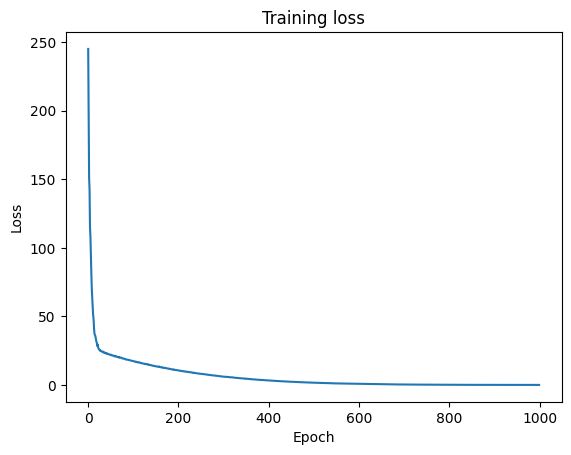

In [99]:
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

<a id='2'></a>
# 3. Scheme BSDE 1

*Sources* : 
- [Deep backward schemes for high-dimensional nonlinear PDEs](https://arxiv.org/pdf/1902.01599)

---

<a id='2_1'></a>
### 3.1 Scheme

<div style="display: flex; justify-content: center;">

<div style="
    border: 1.5px solid black;
    padding: 16px 20px;
    font-family: monospace;
    line-height: 1.5;
    width: 75%;
">

Input:
    Time grid (t₀, ..., t_N)
    Simulated states (S_{t_i}, λ^B_{t_i}, λ^C_{t_i}) and Brownian increments ΔW_{t_i}
    Clean price V(t_i, S_{t_i})
    Neural networks Y_{t_i}(.;θ), Z_{t_i}(.;θ)

Initialize:
    Ŷ_{t_N}(S_{t_N}, λ^B_{t_N}, λ^C_{t_N}) = 0

For i = N-1, ..., 0:

    1. Target:
           target = Ŷ_{t_{i+1}}(S_{t_{i+1}}, λ^B_{t_{i+1}}, λ^C_{t_{i+1}})
           if i = N-1:
               target = 0

    2. Prediction:
           prediction =
               Y_{t_i}(S_{t_i}, λ^B_{t_i}, λ^C_{t_i};θ)
               + [ (r + λ^B_{t_i} + λ^C_{t_i}) Y_{t_i}
                   - (1 - R_C) λ^C_{t_i} V(t_i, S_{t_i}) ] Δt_i
               + Z_{t_i}(S_{t_i}, λ^B_{t_i}, λ^C_{t_i};θ) ΔW_{t_i}

    3. Loss:
           L_i(θ) = E[ | target − prediction |² ]

    4. Update:
           Ŷ_{t_i}(.) = Y_{t_i}(.;θ_i*)
           Ẑ_{t_i}(.) = Z_{t_i}(.;θ_i*)

Return:
    CVA = Ŷ_{t_0}(S_0, λ^B_0, λ^C_0)

</div>
</div>

---
<a id='2_2'></a>
### 3.2 Loss BSDE 1



We define the local loss function at time $t_i$:

$$
\boxed{
L_i(\theta)
=
\mathbb{E}\!\left[
\left|
\hat Y_{t_{i+1}}
-
\Big(
Y_{t_i}
+
\big(
(r+\lambda_{t_i}^B+\lambda_{t_i}^C)Y_{t_i}
-
(1-R)\lambda_{t_i}^C V_{t_i}
\big)\Delta t_i
+
Z_{t_i}\,\Delta W_i
\Big)
\right|^2
\right].
}
$$



The objective is to minimize this loss with respect to $\theta$ at each time step:

$$
\theta_i^* \in \arg\min_{\theta} L_i(\theta).
$$

The procedure is then iterated backward in time, starting from the terminal condition:

$$
\hat Y_{t_N}(x) = 0.
$$


In [100]:
class NN_Y(nn.Module):
    """
    Create 1 NN 
    NN : R^4 -> R
    hidden size : size on-f the hidden layer
    activation function : type of activation
    """
    def __init__(
            self,
            hidden_size: int,
            activation_function: str = 'Tanh',
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, x):
        return self.network(x)


class NN_Z(nn.Module):
    """
    Create 1 NN 
    NN : R^4 -> R^3
    hidden size : size on-f the hidden layer
    activation function : type of activation
    """
    def __init__(
            self,
            hidden_size: int,
            activation_function: str = 'Tanh',
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 3)
        )
        
    def forward(self, x):
        return self.network(x)


class DBDP1(nn.Module):
    """
    Forward simulation of prices trajectories and CVA according the BSDE1 scheme
    
    Output : 
    - Final prices trajectories : R^{n}
    - Final CVA : R^{n}
    - Mean CVA : R
    """
    def __init__(
            self,
            N: int,                       # Number of cut
            n: int,                       # Number of MC iterations
            S0: float,
            lambda0: list,                # List size 2 (initialization of 2 CIR process)
            T: float,
            K: float,
            r: float,
            sigma: list,                  # List size 3 (Stock + 2 CIR process)
            Sigma: list,                  # Correlation matrix (size 3 x 3)
            hidden_size: int,
            R: float,                     # Recovery rate
            speed_reversion_CIR: list,    # List size 2 (params CIR)
            mean_CIR: list,               # List size 2 (params CIR)
            activation_function: str = 'Tanh'
    ):
        super().__init__()  # Heritage nn.Module
        self.N = N
        self.n = n
        self.S0 = float(S0)
        self.lambda0 = lambda0
        self.T = float(T)
        self.K = float(K)
        self.r = float(r)
        self.sigma = sigma
        self.Sigma = torch.as_tensor(Sigma, dtype=torch.float32)
        self.hidden_size = hidden_size
        self.delta_t = self.T / self.N
        self.lambda_B0 = float(lambda0[0])
        self.lambda_C0 = float(lambda0[1])
        self.R = float(R)
        self.speed_reversion_CIR = speed_reversion_CIR
        self.mean_CIR = mean_CIR

        # One pair of networks per time step k = 0, ..., N-1
        self.networks_Y = nn.ModuleList([
            NN_Y(hidden_size=self.hidden_size, activation_function=activation_function) for _ in range(N)
        ])
        self.networks_Z = nn.ModuleList([
            NN_Z(hidden_size=self.hidden_size, activation_function=activation_function) for _ in range(N)
        ])

        self.loss_history = []
        self.step_loss_history = {}

    # ------------------------------------------------------------------
    # Utility functions
    # ------------------------------------------------------------------
    def price_option(self, S0, T):  # Black scholes price
        sigma0 = float(self.sigma[0])
        tau = torch.as_tensor(T, dtype=torch.float32, device=S0.device)
        tau = torch.clamp(tau, min=1e-8)

        d1 = (
            torch.log(S0 / self.K) + (self.r + 0.5 * sigma0 ** 2) * tau
        ) / (sigma0 * torch.sqrt(tau))
        d2 = d1 - sigma0 * torch.sqrt(tau)

        normal_cdf_d1 = 0.5 * (1.0 + torch.erf(d1 / torch.sqrt(torch.tensor(2.0, device=S0.device))))
        normal_cdf_d2 = 0.5 * (1.0 + torch.erf(d2 / torch.sqrt(torch.tensor(2.0, device=S0.device))))

        return S0 * normal_cdf_d1 - self.K * torch.exp(-self.r * tau) * normal_cdf_d2

    def driver(self, k, Y_k, S_k, lambda_B_k, lambda_C_k):
        """
        Compute the driver f_k(Y_k):
            f_k = (r + lambda_B_k + lambda_C_k) Y_k
                  - (1 - R) lambda_C_k V_k
        """
        tau_k = self.T - k * self.delta_t
        V_k = self.price_option(S_k, tau_k)

        return (
            (self.r + lambda_B_k + lambda_C_k) * Y_k
            - (1 - self.R) * lambda_C_k * V_k
        )

    def simulate_paths(self):
        """
        Simulate one MC batch of Euler paths for the state variables.

        Returns
        -------
        S         : tensor of shape (n, N+1)
        lambda_B  : tensor of shape (n, N+1)
        lambda_C  : tensor of shape (n, N+1)
        dW        : tensor of shape (n, N, 3)
        """
        L = torch.linalg.cholesky(self.Sigma)

        # Independent Gaussian increments
        Z_gaussian = torch.randn(self.n, self.N, 3, dtype=torch.float32)

        # Correlated Brownian increments
        dW = Z_gaussian @ L.T * (self.delta_t ** 0.5)

        S = torch.zeros(self.n, self.N + 1, dtype=torch.float32)
        lambda_B = torch.zeros(self.n, self.N + 1, dtype=torch.float32)
        lambda_C = torch.zeros(self.n, self.N + 1, dtype=torch.float32)

        S[:, 0] = self.S0
        lambda_B[:, 0] = self.lambda_B0
        lambda_C[:, 0] = self.lambda_C0

        for k in range(self.N):
            # Price scheme : Black Scholes Euler
            S[:, k + 1] = (
                S[:, k]
                + self.r * S[:, k] * self.delta_t
                + self.sigma[0] * S[:, k] * dW[:, k, 0]
            )

            # CIR scheme for lambda^B
            lambda_B[:, k + 1] = (
                lambda_B[:, k]
                + self.speed_reversion_CIR[0] * (self.mean_CIR[0] - lambda_B[:, k]) * self.delta_t
                + self.sigma[1] * torch.sqrt(torch.clamp(lambda_B[:, k], min=0.0)) * dW[:, k, 1]
            )

            # CIR scheme for lambda^C
            lambda_C[:, k + 1] = (
                lambda_C[:, k]
                + self.speed_reversion_CIR[1] * (self.mean_CIR[1] - lambda_C[:, k]) * self.delta_t
                + self.sigma[2] * torch.sqrt(torch.clamp(lambda_C[:, k], min=0.0)) * dW[:, k, 2]
            )

            lambda_B[:, k + 1] = torch.clamp(lambda_B[:, k + 1], min=0.0)
            lambda_C[:, k + 1] = torch.clamp(lambda_C[:, k + 1], min=0.0)

        return S, lambda_B, lambda_C, dW

    def build_input(self, k, S_k, lambda_B_k, lambda_C_k):
        """
        Build input x_k = (t_k, S_k, lambda_B_k, lambda_C_k) of shape (n, 4)
        """
        t_k = torch.full((S_k.shape[0], 1), k * self.delta_t, dtype=torch.float32)
        S_k = S_k.unsqueeze(1)
        lambda_B_k = lambda_B_k.unsqueeze(1)
        lambda_C_k = lambda_C_k.unsqueeze(1)

        return torch.cat([t_k, S_k, lambda_B_k, lambda_C_k], dim=1)

    def one_step_prediction(self, k, S_k, lambda_B_k, lambda_C_k, dW_k):
        """
        Compute the local prediction of Y_{k+1} from time k:
            Y_{k+1}^pred = Y_k + ((r + lambda_B_k + lambda_C_k) * Y_k - (1 - R_C) * lambda_C_k * V(t_k, S_k)) * dt + Z_k · dW_k
        """
        x_k = self.build_input(k, S_k, lambda_B_k, lambda_C_k)

        Y_k = self.networks_Y[k](x_k).squeeze(1)   # (n,)
        Z_k = self.networks_Z[k](x_k)              # (n, 3)

        f_k = self.driver(k, Y_k, S_k, lambda_B_k, lambda_C_k)
        Z_dW_k = torch.sum(Z_k * dW_k, dim=1)

        Y_pred = Y_k + f_k * self.delta_t + Z_dW_k
        return Y_pred

    def local_loss(self, Y_target, Y_pred):
        return ((Y_target - Y_pred) ** 2).mean()

    # ------------------------------------------------------------------
    # Local target construction
    # ------------------------------------------------------------------
    def compute_target(self, k, S_next, lambda_B_next, lambda_C_next):
        """
        Return the local target for step k.

        If k = N-1:
            target = 0

        Else:
            target = U_{k+1}(t_{k+1}, X_{k+1}) evaluated with frozen next network
        """
        if k == self.N - 1:
            return torch.zeros_like(S_next)

        with torch.no_grad():
            x_next = self.build_input(k + 1, S_next, lambda_B_next, lambda_C_next)
            target = self.networks_Y[k + 1](x_next).squeeze(1)

        return target

    # ------------------------------------------------------------------
    # Warm start
    # ------------------------------------------------------------------
    def copy_weights(self, source_k, target_k):
        """
        Initialize step target_k with weights from source_k.
        """
        self.networks_Y[target_k].load_state_dict(
            copy.deepcopy(self.networks_Y[source_k].state_dict())
        )
        self.networks_Z[target_k].load_state_dict(
            copy.deepcopy(self.networks_Z[source_k].state_dict())
        )

    # ------------------------------------------------------------------
    # Training of one local problem
    # ------------------------------------------------------------------
    def train_one_step(self, k, lr, training_iterations, epsilon_loss):
        """
        Train local networks (Y_k, Z_k) only.

        Parameters
        ----------
        k : int
            time step to train
        lr : float
        training_iterations : int
        epsilon_loss : float
        """
        params = list(self.networks_Y[k].parameters()) + list(self.networks_Z[k].parameters())

        optimizer = torch.optim.SGD(params, lr=lr)

        local_losses = []

        # Fixed batch
        S, lambda_B, lambda_C, dW = self.simulate_paths()
        S_k = S[:, k]
        S_next = S[:, k + 1]
        lambda_B_k = lambda_B[:, k]
        lambda_B_next = lambda_B[:, k + 1]
        lambda_C_k = lambda_C[:, k]
        lambda_C_next = lambda_C[:, k + 1]
        dW_k = dW[:, k]

        for _ in range(training_iterations):
            optimizer.zero_grad()

            Y_target = self.compute_target(k, S_next, lambda_B_next, lambda_C_next)
            Y_pred = self.one_step_prediction(k, S_k, lambda_B_k, lambda_C_k, dW_k)

            loss = self.local_loss(Y_target, Y_pred)
            loss.backward()
            optimizer.step()

            local_losses.append(loss.item())

            if loss.item() < epsilon_loss:
                break

        self.step_loss_history[k] = local_losses
        self.loss_history.append(local_losses[-1])

        if k == self.N - 1:
            self.first_loss = local_losses

    # ------------------------------------------------------------------
    # Global backward training
    # ------------------------------------------------------------------
    def train_model(
        self,
        lr: float = 1e-2,
        training_iterations: int = 1000,
        epsilon_loss: float = 1e-1
    ):
        """
        Backward training:
            k = N-1, N-2, ..., 0
        """
        self.loss_history = []
        self.step_loss_history = {}

        for k in range(self.N - 1, -1, -1):
            # warm start from the already trained network on the right
            if k < self.N - 1:
                self.copy_weights(source_k=k + 1, target_k=k)

            self.train_one_step(
                k=k,
                lr=lr,
                training_iterations=training_iterations,
                epsilon_loss=epsilon_loss
            )

        return self.CVA()

    # ------------------------------------------------------------------
    # Final price
    # ------------------------------------------------------------------
    def CVA(self):
        """
        Return estimated Y_0 = U_0(0, S0, lambda_B0, lambda_C0)
        """
        with torch.no_grad():
            x0 = torch.tensor([[0.0, self.S0, self.lambda_B0, self.lambda_C0]], dtype=torch.float32)
            Y0 = self.networks_Y[0](x0).item()

        self.Y_0 = Y0
        return Y0

In [101]:
model = DBDP1(
    N=10,
    n=1000,
    S0=100.0,
    lambda0=[0.02, 0.03],
    T=1.0,
    K=100.0,
    r=0.02,
    sigma=[0.2, 0.2, 0.2],
    Sigma=[
        [1.0, 0.3, 0.2],
        [0.3, 1.0, 0.4],
        [0.2, 0.4, 1.0]
    ],
    hidden_size=4,
    R=0.4,
    speed_reversion_CIR=[1.0, 1.5],
    mean_CIR=[0.02, 0.03]
)

CVA = model.train_model(
    lr=1e-1,
    training_iterations=1_000,
    epsilon_loss=1e-4
)

print("Estimated CVA:", CVA)

Estimated CVA: 0.16866281628608704


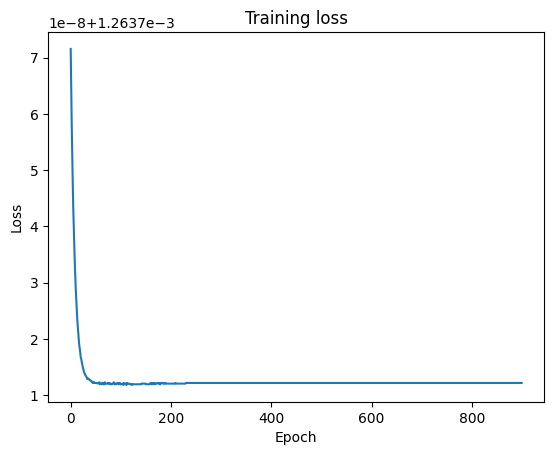

In [102]:
plt.plot(model.first_loss[100:])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

<a id='3'></a>
# 4. Scheme BSDE 2

*Sources* : 
- [Deep backward schemes for high-dimensional nonlinear PDEs](https://arxiv.org/pdf/1902.01599)

---

<a id='3_1'></a>
### 4.1 Scheme

<div style="display: flex; justify-content: center;">

<div style="
    border: 1.5px solid black;
    padding: 16px 20px;
    font-family: monospace;
    line-height: 1.5;
    width: 75%;
">

Input:
    Time grid (t₀, ..., t_N)
    Simulated states (S_{t_i}, λ^B_{t_i}, λ^C_{t_i}) and Brownian increments ΔW_{t_i}
    Clean price V(t_i, S_{t_i})
    Neural networks Y_{t_i}(.;θ)

Initialize:
    Ŷ_{t_N}(S_{t_N}, λ^B_{t_N}, λ^C_{t_N}) = 0

For i = N-1, ..., 0:

    1. Target:
           target = Ŷ_{t_{i+1}}(S_{t_{i+1}}, λ^B_{t_{i+1}}, λ^C_{t_{i+1}})
           if i = N-1:
               target = 0

    2. Gradient computation:
           Z_{t_i}(t_i, S_{t_i}, λ^B_{t_i}, λ^C_{t_i}) =
               Σ_X(t_i, S_{t_i}, λ^B_{t_i}, λ^C_{t_i})ᵀ ∇_x Y_{t_i}(t_i, S_{t_i}, λ^B_{t_i}, λ^C_{t_i};θ)
           (computed via automatic differentiation)

    3. Prediction:
           prediction =
               Y_{t_i}(t_i, S_{t_i}, λ^B_{t_i}, λ^C_{t_i};θ)
               + [ (r + λ^B_{t_i} + λ^C_{t_i}) Y_{t_i}
                   - (1 - R_C) λ^C_{t_i} V(t_i, S_{t_i}) ] Δt_i
               + Z_{t_i}(t_i, S_{t_i}, λ^B_{t_i}, λ^C_{t_i}) ΔW_{t_i}

    4. Loss:
           L_i(θ) = E[ | target − prediction |² ]

    5. Update:
           Ŷ_{t_i}(.) = Y_{t_i}(.;θ_i*)
           Ẑ_{t_i}(.) = Σ_Xᵀ ∇_x Y_{t_i}(.;θ_i*)

Return:
    CVA = Ŷ_{t_0}(0, S_0, λ^B_0, λ^C_0)

</div>
</div>

---
<a id='3_2'></a>
### 4.2 Loss BSDE 2



We define the local loss function at time $t_i$:

$$
\boxed{
L_i(\theta)
=
\mathbb{E}\!\left[
\left|
\hat Y_{t_{i+1}}
-
\Big(
Y_{t_i}
+
\big(
(r+\lambda_{t_i}^B+\lambda_{t_i}^C)Y_{t_i}
-
(1-R)\lambda_{t_i}^C V_{t_i}
\big)\Delta t_i
+
Z_{t_i}\,\Delta W_i
\Big)
\right|^2
\right].
}
$$



The objective is to minimize this loss with respect to $\theta$ at each time step:

$$
\theta_i^* \in \arg\min_{\theta} L_i(\theta).
$$

The procedure is then iterated backward in time, starting from the terminal condition:

$$
\hat Y_{t_N}(x) = 0.
$$


In [103]:
class NN(nn.Module):
    """
    Create 1 NN 
    NN : R^4 -> R
    hidden size : size on-f the hidden layer
    activation function : type of activation
    """
    def __init__(
            self,
            hidden_size: int,
            activation_function: str = 'Tanh',
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, x):
        return self.network(x)


class DBDP2(nn.Module):
    """
    Implementation of a DBDP2-type scheme for CVA.

    Main idea:
    - Y_k(t_k, S_k, lambda^B_k, lambda^C_k) approximates Y_k
    - Z_k(t_k, S_k, lambda^B_k, lambda^C_k) evaluated by differentiate Y_k(t_k, S_k, lambda^B_k, lambda^C_k)
    - At each date k, we solve a local regression problem:
          target = Y_{k+1}(t_{k+1}, S_{k+1}, lambda^B_{k+1}, lambda^C_{k+1})   if k < N-1
                 = 0                                                            if k = N-1

          pred   = Y_k + f(Y_k) dt + Z_k dW
    """

    def __init__(
        self,
        N: int,
        n: int,
        S0: float,
        lambda0: list,                # List size 2 (initialization of 2 CIR process)
        T: float,
        K: float,
        r: float,
        sigma: list,                  # List size 3 (Stock + 2 CIR process)
        Sigma: list,                  # Correlation matrix (size 3 x 3)
        hidden_size: int,
        R: float,                     # Recovery rate
        speed_reversion_CIR: list,    # List size 2 (params CIR)
        mean_CIR: list,               # List size 2 (params CIR)
        activation_function: str = "Tanh"
    ):
        super().__init__()

        self.N = N                  # number of time steps
        self.n = n                  # Monte Carlo batch size
        self.S0 = float(S0)
        self.lambda0 = lambda0
        self.T = float(T)
        self.K = float(K)
        self.r = float(r)
        self.sigma = sigma
        self.Sigma = torch.as_tensor(Sigma, dtype=torch.float32)
        self.hidden_size = hidden_size
        self.delta_t = self.T / self.N
        self.lambda_B0 = float(lambda0[0])
        self.lambda_C0 = float(lambda0[1])
        self.R = float(R)
        self.speed_reversion_CIR = speed_reversion_CIR
        self.mean_CIR = mean_CIR

        # One pair of networks per time step k = 0, ..., N-1
        self.networks_Y = nn.ModuleList([
            NN(hidden_size, activation_function) for _ in range(N)
        ])

        self.loss_history = []
        self.step_loss_history = {}

    # ------------------------------------------------------------------
    # Utility functions
    # ------------------------------------------------------------------
    def price_option(self, S0, T):
        """
        Black Scholes clean price
        """
        sigma0 = float(self.sigma[0])
        tau = torch.as_tensor(T, dtype=torch.float32, device=S0.device)
        tau = torch.clamp(tau, min=1e-8)

        d1 = (
            torch.log(S0 / self.K) + (self.r + 0.5 * sigma0 ** 2) * tau
        ) / (sigma0 * torch.sqrt(tau))
        d2 = d1 - sigma0 * torch.sqrt(tau)

        normal_cdf_d1 = 0.5 * (1.0 + torch.erf(d1 / torch.sqrt(torch.tensor(2.0, device=S0.device))))
        normal_cdf_d2 = 0.5 * (1.0 + torch.erf(d2 / torch.sqrt(torch.tensor(2.0, device=S0.device))))

        return S0 * normal_cdf_d1 - self.K * torch.exp(-self.r * tau) * normal_cdf_d2

    def driver(self, k, Y_k, S_k, lambda_B_k, lambda_C_k):
        """
        Compute the driver f_k(Y_k):
            f_k = (r + lambda_B_k + lambda_C_k) Y_k
                  - (1 - R) lambda_C_k V_k
        """
        tau_k = self.T - k * self.delta_t
        V_k = self.price_option(S_k, tau_k)

        return (
            (self.r + lambda_B_k + lambda_C_k) * Y_k
            - (1 - self.R) * lambda_C_k * V_k
        )

    def simulate_paths(self):
        """
        Simulate one MC batch of Euler paths for the state variables.

        Returns
        -------
        S         : tensor of shape (n, N+1)
        lambda_B  : tensor of shape (n, N+1)
        lambda_C  : tensor of shape (n, N+1)
        dW        : tensor of shape (n, N, 3)
        """
        L = torch.linalg.cholesky(self.Sigma)

        # Independent Gaussian increments
        Z_gaussian = torch.randn(self.n, self.N, 3, dtype=torch.float32)

        # Correlated Brownian increments
        dW = Z_gaussian @ L.T * (self.delta_t ** 0.5)

        S = torch.zeros(self.n, self.N + 1)
        lambda_B = torch.zeros(self.n, self.N + 1)
        lambda_C = torch.zeros(self.n, self.N + 1)

        S[:, 0] = self.S0
        lambda_B[:, 0] = self.lambda_B0
        lambda_C[:, 0] = self.lambda_C0

        for k in range(self.N):
            S[:, k + 1] = (
                S[:, k]
                + self.r * S[:, k] * self.delta_t
                + self.sigma[0] * S[:, k] * dW[:, k, 0]
            )

            lambda_B[:, k + 1] = (
                lambda_B[:, k]
                + self.speed_reversion_CIR[0] * (self.mean_CIR[0] - lambda_B[:, k]) * self.delta_t
                + self.sigma[1] * torch.sqrt(torch.clamp(lambda_B[:, k], min=0.0)) * dW[:, k, 1]
            )

            lambda_C[:, k + 1] = (
                lambda_C[:, k]
                + self.speed_reversion_CIR[1] * (self.mean_CIR[1] - lambda_C[:, k]) * self.delta_t
                + self.sigma[2] * torch.sqrt(torch.clamp(lambda_C[:, k], min=0.0)) * dW[:, k, 2]
            )

            lambda_B[:, k + 1] = torch.clamp(lambda_B[:, k + 1], min=0.0)
            lambda_C[:, k + 1] = torch.clamp(lambda_C[:, k + 1], min=0.0)

        return S, lambda_B, lambda_C, dW

    def build_input(self, k, S_k, lambda_B_k, lambda_C_k):
        """
        Build input x_k = (t_k, S_k, lambda_B_k, lambda_C_k) of shape (n, 4)
        """
        t_k = torch.full((S_k.shape[0], 1), k * self.delta_t)
        S_k = S_k.unsqueeze(1)
        lambda_B_k = lambda_B_k.unsqueeze(1)
        lambda_C_k = lambda_C_k.unsqueeze(1)
        return torch.cat([t_k, S_k, lambda_B_k, lambda_C_k], dim=1)

    def one_step_prediction(self, k, S_k, lambda_B_k, lambda_C_k, dW_k):
        """
        Compute the local prediction of Y_{k+1} from time k:
            Y_{k+1}^pred = Y_k + ((r + lambda_B_k + lambda_C_k) * Y_k - (1 - R_C) * lambda_C_k * V(t_k, S_k)) * dt + Z_k · dW_k
        """
        x_k = self.build_input(k, S_k, lambda_B_k, lambda_C_k).detach().requires_grad_(True)

        Y_k = self.networks_Y[k](x_k).squeeze(1)   # (n,)

        grad_Y = torch.autograd.grad(
            outputs=Y_k,
            inputs=x_k,
            grad_outputs=torch.ones_like(Y_k),
            create_graph=True
        )[0]

        dY_dS = grad_Y[:, 1]
        dY_dlambda_B = grad_Y[:, 2]
        dY_dlambda_C = grad_Y[:, 3]

        Z_k_S = self.sigma[0] * S_k * dY_dS
        Z_k_B = self.sigma[1] * torch.sqrt(torch.clamp(lambda_B_k, min=0.0)) * dY_dlambda_B
        Z_k_C = self.sigma[2] * torch.sqrt(torch.clamp(lambda_C_k, min=0.0)) * dY_dlambda_C

        Z_k = torch.stack([Z_k_S, Z_k_B, Z_k_C], dim=1)   # (n, 3)

        f_k = self.driver(k, Y_k, S_k, lambda_B_k, lambda_C_k)
        Z_dW_k = torch.sum(Z_k * dW_k, dim=1)

        Y_pred = Y_k + f_k * self.delta_t + Z_dW_k
        return Y_pred

    def local_loss(self, Y_target, Y_pred):
        return ((Y_target - Y_pred) ** 2).mean()

    # ------------------------------------------------------------------
    # Local target construction
    # ------------------------------------------------------------------
    def compute_target(self, k, S_next, lambda_B_next, lambda_C_next):
        """
        Return the local target for step k.

        If k = N-1:
            target = 0

        Else:
            target = U_{k+1}(t_{k+1}, S_{k+1}, lambda^B_{k+1}, lambda^C_{k+1}) evaluated with frozen next network
        """
        if k == self.N - 1:
            return torch.zeros_like(S_next)

        with torch.no_grad():
            x_next = self.build_input(k + 1, S_next, lambda_B_next, lambda_C_next)
            target = self.networks_Y[k + 1](x_next).squeeze(1)

        return target

    # ------------------------------------------------------------------
    # Warm start
    # ------------------------------------------------------------------
    def copy_weights(self, source_k, target_k):
        """
        Initialize step target_k with weights from source_k.
        """
        self.networks_Y[target_k].load_state_dict(
            copy.deepcopy(self.networks_Y[source_k].state_dict())
        )

    # ------------------------------------------------------------------
    # Training of one local problem
    # ------------------------------------------------------------------
    def train_one_step(self, k, lr, training_iterations, epsilon_loss):
        """
        Train local networks (Z_k)_k.

        Parameters
        ----------
        k : int
            time step to train
        lr : float
        training_iterations : int
        epsilon_loss : float (accelerate the training : with warm start, the last NN converge quicker than the first one)
        """
        params = list(self.networks_Y[k].parameters())

        optimizer = torch.optim.SGD(params, lr=lr) # SGD : same in the paper
        #optimizer = torch.optim.Adam(params, lr=lr)

        local_losses = []

        # Fixed batch
        S, lambda_B, lambda_C, dW = self.simulate_paths()
        S_k = S[:, k]
        S_next = S[:, k + 1]
        lambda_B_k = lambda_B[:, k]
        lambda_B_next = lambda_B[:, k + 1]
        lambda_C_k = lambda_C[:, k]
        lambda_C_next = lambda_C[:, k + 1]
        dW_k = dW[:, k]

        for _ in range(training_iterations):
            optimizer.zero_grad()

            Y_target = self.compute_target(k, S_next, lambda_B_next, lambda_C_next)
            Y_pred = self.one_step_prediction(k, S_k, lambda_B_k, lambda_C_k, dW_k)

            loss = self.local_loss(Y_target, Y_pred)
            loss.backward()
            optimizer.step()

            local_losses.append(loss.item())

            # Accelerate training
            if loss.item() < epsilon_loss:
                break

        self.step_loss_history[k] = local_losses
        self.loss_history.append(local_losses[-1])

        # Check the first convergence (the most important) for parameter tuning
        if k == self.N - 1:
            self.first_loss = local_losses

    # ------------------------------------------------------------------
    # Global backward training
    # ------------------------------------------------------------------
    def train_model(
        self,
        lr: float = 1e-2,
        training_iterations: int = 1000,
        epsilon_loss: int = 1e-1
    ):
        """
        Backward training:
            k = N-1, N-2, ..., 0
        """
        self.loss_history = []
        self.step_loss_history = {}

        for k in range(self.N - 1, -1, -1):
            # warm start from the already trained network on the right
            if k < self.N - 1:
                self.copy_weights(source_k=k + 1, target_k=k)

            self.train_one_step(
                k=k,
                lr=lr,
                training_iterations=training_iterations,
                epsilon_loss=epsilon_loss
            )

        return self.price()

    # ------------------------------------------------------------------
    # Final price
    # ------------------------------------------------------------------
    def price(self):
        """
        Return estimated Y_0 = U_0(0, S0, lambda_B0, lambda_C0)
        """
        with torch.no_grad():
            x0 = torch.tensor([[0.0, self.S0, self.lambda_B0, self.lambda_C0]], dtype=torch.float32)
            Y0 = self.networks_Y[0](x0).item()

        self.Y_0 = Y0
        return Y0

In [104]:
model = DBDP2(
    N=10,
    n=1000,
    S0=100.0,
    lambda0=[0.02, 0.03],
    T=1.0,
    K=100.0,
    r=0.02,
    sigma=[0.2, 0.2, 0.2],
    Sigma=[
        [1.0, 0.3, 0.2],
        [0.3, 1.0, 0.4],
        [0.2, 0.4, 1.0]
    ],
    hidden_size=4,
    R=0.4,
    speed_reversion_CIR=[1.0, 1.5],
    mean_CIR=[0.02, 0.03]
)

price = model.train_model(
    lr=1e-1,
    training_iterations=1000,
    epsilon_loss=1e-5
)

print("Estimated CVA:", price)

Estimated CVA: 0.16018037497997284


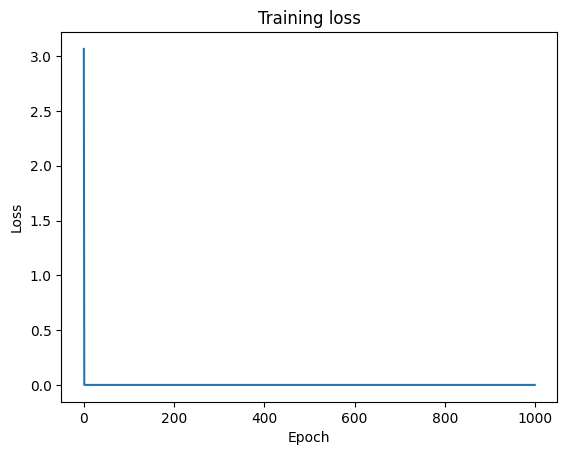

In [105]:
plt.plot(model.first_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

<a id='4'></a>
# 5. Results

---

<a id='4_1'></a>
### 5.1 Table of results

In [107]:
n_runs = 10

results_original = []
results_scheme1 = []
results_scheme2 = []

times_original = []
times_scheme1 = []
times_scheme2 = []

for run in range(n_runs):
    # ---------------------------
    # Original scheme
    # ---------------------------
    start = time.time()

    model = training(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03],
        lr=1e-1,
        training_iterations=10_000
    )

    model.train_model()
    cva_original = model.price_return()

    end = time.time()

    results_original.append(cva_original)
    times_original.append(end - start)

    # ---------------------------
    # Scheme 1
    # ---------------------------
    start = time.time()

    model = DBDP1(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03]
    )

    cva_scheme1 = model.train_model(
        lr=1e-1,
        training_iterations=10_000,
        epsilon_loss=1e-4
    )

    end = time.time()

    results_scheme1.append(cva_scheme1)
    times_scheme1.append(end - start)

    # ---------------------------
    # Scheme 2
    # ---------------------------
    start = time.time()

    model = DBDP2(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03]
    )

    cva_scheme2 = model.train_model(
        lr=1e-1,
        training_iterations=10_000,
        epsilon_loss=1e-5
    )

    end = time.time()

    results_scheme2.append(cva_scheme2)
    times_scheme2.append(end - start)


# ---------------------------
# Summary table
# ---------------------------
summary = pd.DataFrame({
    "Method": ["Original scheme", "Scheme 1", "Scheme 2"],
    "Mean CVA": [
        np.mean(results_original),
        np.mean(results_scheme1),
        np.mean(results_scheme2)
    ],
    "Std CVA": [
        np.std(results_original, ddof=1),
        np.std(results_scheme1, ddof=1),
        np.std(results_scheme2, ddof=1)
    ],
    "Mean time (s)": [
        np.mean(times_original),
        np.mean(times_scheme1),
        np.mean(times_scheme2)
    ]
})

print(summary)

            Method  Mean CVA   Std CVA  Mean time (s)
0  Original scheme  0.165066  0.009530     260.275605
1         Scheme 1  0.169294  0.002317      75.571418
2         Scheme 2  0.170350  0.002953      89.791082


<a id='4_2'></a>
### 5.2 Sensitivities

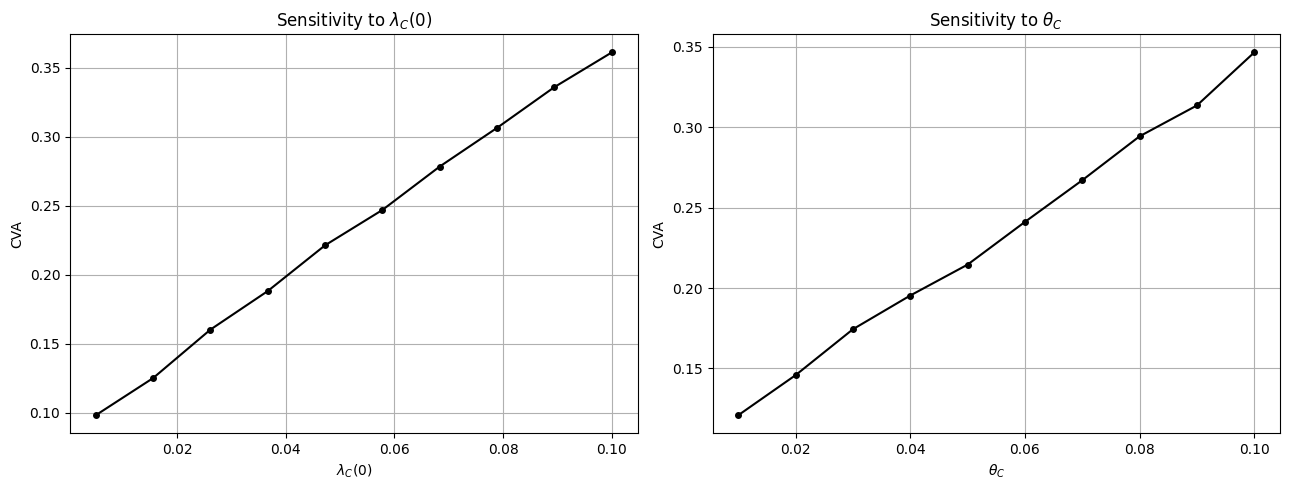

In [111]:
lambdaC0_values = np.linspace(0.005, 0.10, 10)
thetaC_values = np.linspace(0.01, 0.10, 10)

cva_values_lambdaC0 = []
cva_values_thetaC = []

# -----------------------------------
# Sensitivity to lambda_C(0)
# -----------------------------------
for lambdaC0 in lambdaC0_values:
    model = DBDP2(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, float(lambdaC0)],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03]
    )

    cva = model.train_model(
        lr=1e-1,
        training_iterations=1000,
        epsilon_loss=1e-5
    )

    cva_values_lambdaC0.append(cva)

# -----------------------------------
# Sensitivity to theta_C
# -----------------------------------
for thetaC in thetaC_values:
    model = DBDP2(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, float(thetaC)]
    )

    cva = model.train_model(
        lr=1e-1,
        training_iterations=1000,
        epsilon_loss=1e-5
    )

    cva_values_thetaC.append(cva)

# -----------------------------------
# Plot
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lambdaC0_values, cva_values_lambdaC0, color="black", marker="o", markersize=4)
axes[0].set_title(r"Sensitivity to $\lambda_C(0)$")
axes[0].set_xlabel(r"$\lambda_C(0)$")
axes[0].set_ylabel("CVA")
axes[0].grid(True)

axes[1].plot(thetaC_values, cva_values_thetaC, color="black", marker="o", markersize=4)
axes[1].set_title(r"Sensitivity to $\theta_C$")
axes[1].set_xlabel(r"$\theta_C$")
axes[1].set_ylabel("CVA")
axes[1].grid(True)

plt.tight_layout()
plt.show()

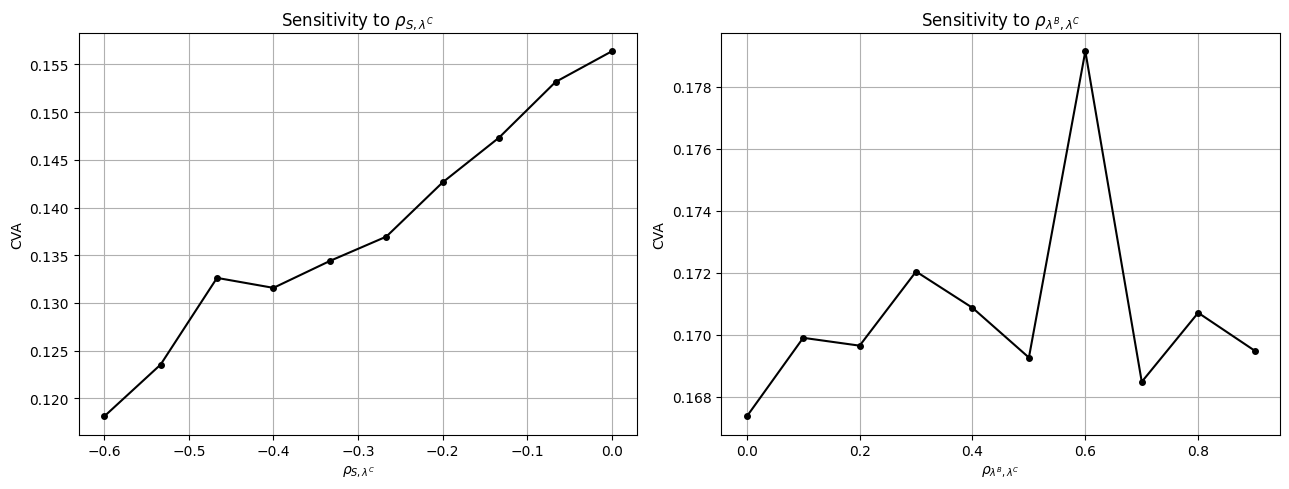

In [115]:
rho_SC_values = np.linspace(-0.6, 0, 10)
rho_BC_values = np.linspace(0, 0.9, 10)

cva_values_rhoSC = []
cva_values_rhoBC = []

# -----------------------------------
# Sensitivity to rho_SC
# -----------------------------------
for rho_SC in rho_SC_values:
    model = DBDP2(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, float(rho_SC)],
            [0.3, 1.0, 0.4],
            [float(rho_SC), 0.4, 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03]
    )

    cva = model.train_model(
        lr=1e-1,
        training_iterations=1000,
        epsilon_loss=1e-5
    )

    cva_values_rhoSC.append(cva)

# -----------------------------------
# Sensitivity to rho_BC
# -----------------------------------
for rho_BC in rho_BC_values:
    model = DBDP2(
        N=10,
        n=1000,
        S0=100.0,
        lambda0=[0.02, 0.03],
        T=1.0,
        K=100.0,
        r=0.02,
        sigma=[0.2, 0.2, 0.2],
        Sigma=[
            [1.0, 0.3, 0.2],
            [0.3, 1.0, float(rho_BC)],
            [0.2, float(rho_BC), 1.0]
        ],
        hidden_size=4,
        R=0.4,
        speed_reversion_CIR=[1.0, 1.5],
        mean_CIR=[0.02, 0.03]
    )

    cva = model.train_model(
        lr=1e-1,
        training_iterations=1000,
        epsilon_loss=1e-5
    )

    cva_values_rhoBC.append(cva)

# -----------------------------------
# Plot
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(rho_SC_values, cva_values_rhoSC, color="black", marker="o", markersize=4)
axes[0].set_title(r"Sensitivity to $\rho_{S,\lambda^C}$")
axes[0].set_xlabel(r"$\rho_{S,\lambda^C}$")
axes[0].set_ylabel("CVA")
axes[0].grid(True)

axes[1].plot(rho_BC_values, cva_values_rhoBC, color="black", marker="o", markersize=4)
axes[1].set_title(r"Sensitivity to $\rho_{\lambda^B,\lambda^C}$")
axes[1].set_xlabel(r"$\rho_{\lambda^B,\lambda^C}$")
axes[1].set_ylabel("CVA")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<a id='5'></a>
# 6. Appendix :

---

<a id='5_1'></a>
### 6.1 Construction of BSDE Scheme :

We start from the unilateral CVA representation:


$$
Y_t
:=
\mathbb{E}^{\mathbb{Q}}\left[
\int_t^T
e^{-\int_t^u c_s\,ds}\, g_u
\,du
\;\middle|\;
\mathcal{F}_t
\right].
$$

By construction, $Y_t$ represents the CVA value at time $t$, and in particular

$$
Y_0 = \text{CVA},
\qquad
Y_T = 0.
$$

---

#### Markovian representation

Let us define the state process

$$
X_t := \bigl(S_t,\lambda_t^B,\lambda_t^C\bigr).
$$

Under the present framework, the dynamics of $X_t$ are given by

$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t^S,
$$

$$
d\lambda_t^B = \kappa_B (\theta_B - \lambda_t^B)\,dt + \eta_B \sqrt{\lambda_t^B}\,dW_t^B,
$$

$$
d\lambda_t^C = \kappa_C (\theta_C - \lambda_t^C)\,dt + \eta_C \sqrt{\lambda_t^C}\,dW_t^C.
$$

Since $(S_t,\lambda_t^B,\lambda_t^C)$ is a Markov diffusion, there exists a deterministic function

$$
u : [0,T]\times \mathbb{R}_+^3 \to \mathbb{R}
$$

such that

$$
\boxed{
Y_t = u(t,X_t)=u\bigl(t,S_t,\lambda_t^B,\lambda_t^C\bigr).
}
$$

Hence, the CVA is represented as a function of the current state only, even though its definition involves an integral over future paths.

---

#### PDE associated with the CVA

The process $Y_t$ is of the standard Feynman-Kac form

$$
Y_t
=
\mathbb{E}^{\mathbb{Q}}\left[
\int_t^T
e^{-\int_t^u c_s\,ds}\, g_u
\,du
\;\middle|\;
\mathcal{F}_t
\right],
$$

so that the associated pricing function $u$ solves the linear PDE

$$
\boxed{
\partial_t u + \mathcal{L}u - c\,u + g = 0,
\qquad
u(T,\cdot)=0,
}
$$

where $\mathcal{L}$ denotes the infinitesimal generator of the Markov process $X_t$.


Therefore, the CVA PDE is

$$
\partial_t u + \mathcal{L}u
-
(r+\lambda^B+\lambda^C)u
+
(1-R_C)\lambda^C V^+ = 0,
\qquad
u(T,\cdot)=0.
$$


$$
\boxed{
\partial_t u + \mathcal{L}u
=
(r+\lambda^B+\lambda^C)u
-
(1-R_C)\lambda^C V^+}\tag{1}
$$

---

#### Application of Itô's formula

We now recover the BSDE formulation from the Markovian representation

$$
Y_t = u(t,X_t).
$$


Applying Itô's formula to $u(t,X_t)$ yields

$$ 
\boxed{
dY_t = \left(\partial_t u + \mathcal{L}u\right)(t,X_t)\,dt + Z_t \cdot dW_t, 
}\tag{2}
$$

Hence, if we write $W_t=(W_t^S,W_t^B,W_t^C)$, the process $Z_t$ is given by

$$
Z_t
=
\left(
\sigma S_t\,\partial_s u(t,X_t),\;
\eta_B\sqrt{\lambda_t^B}\,\partial_{\lambda^B}u(t,X_t),\;
\eta_C\sqrt{\lambda_t^C}\,\partial_{\lambda^C}u(t,X_t)
\right).
$$


By plugging $(1) \implies (2)$ :

The CVA process satisfies the backward stochastic differential equation

$$
\boxed{
dY_t
=
\Bigl(
(r+\lambda_t^B+\lambda_t^C)Y_t
-
(1-R_C)\lambda_t^C V_t^+
\Bigr)\,dt
+
Z_t\cdot dW_t,
\qquad
Y_T=0.
}
$$

---

<a id='5_2'></a>
### 6.2 Neural network approximation of the control process $(Z_t)_{t \ge 0}$


We approximate the control process $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks.

Let $i \in \{0,\dots,N-1\}$. For each time step $t_i$, we introduce a neural network

$$
NN_i : \mathbb{R}^2 \rightarrow \mathbb{R}
$$


More precisely, each neural network is defined as a composition of affine maps and nonlinear activation functions. Let $L \ge 1$ be the number of layers and $(m_\ell)_{\ell=0,\dots,L}$ the layer dimensions, with $m_0 = 2 \quad (t, S_t), \qquad m_L = 1 \quad (Z_t).$

The neural network $NN_i$ is defined by

$$
NN_i(x) = A_L \circ \rho \circ A_{L-1} \circ \dots \circ \rho \circ A_1(x),
\qquad x \in \mathbb{R}^2
$$

where for $\ell = 1,\dots,L$

$$
A_\ell(x) = W_\ell x + b_\ell
$$

are affine transformations with weight matrices $W_\ell$ and bias vectors $b_\ell$, and $\rho : \mathbb{R} \rightarrow \mathbb{R}$ is a nonlinear activation function applied component-wise.

The parameters of the neural network are therefore the collection $\theta_i = (W_\ell, b_\ell)_{\ell=1,\dots,L}.$

Finally we approximate

$$
Z_{t_i} \approx NN_i(t_i,S_{t_i};\theta_i).
$$